In [1]:
from pathlib import Path

import pandas as pd
from plots import plot_c

In [2]:
cmap = {
    "home": (0.5529411764705883, 0.8274509803921568, 0.7803921568627451),
    "other": (1.0, 1.0, 0.7019607843137254),
    "shop": (0.7450980392156863, 0.7294117647058823, 0.8549019607843137),
    "work": (0.984313725490196, 0.5019607843137255, 0.4470588235294118),
    "escort": (0.5019607843137255, 0.6941176470588235, 0.8274509803921568),
    "visit": (0.9921568627450981, 0.7058823529411765, 0.3843137254901961),
    "education": (0.7019607843137254, 0.8705882352941177, 0.4117647058823529),
    "medical": (0.9882352941176471, 0.803921568627451, 0.8980392156862745),
    "travel": (0.8509803921568627, 0.8509803921568627, 0.8509803921568627),
}

batch_root = Path("../../logs/foundations/C")

batch_paths = {
    "C0 (baseline)": batch_root / "baseline",
    "C1 (temporal)": batch_root / "temporal_transfer",
    "C2 (spatial)": batch_root / "spatial_transfer",
}

# find data
data_root = Path("../../tmp/foundation")
target_schedules = pd.read_csv(
    data_root / "experiment_c" / "nts_activities_2024.csv"
)
acts = list(target_schedules.act.value_counts(ascending=False).index)
class_map = {n: i for i, n in enumerate(acts)}

target_attributes = pd.read_csv(
    data_root / "experiment_c" / "nts_attributes_2024.csv"
)


def latest(path: Path):
    versions = sorted(
        [
            d
            for d in path.iterdir()
            if d.is_dir() and d.name.startswith("version")
        ]
    )
    return path.name, versions[-1]


def iter_models(path: Path):
    for dir in path.iterdir():

        if dir.is_dir():

            yield latest(dir)


def find_nth(path: Path, n=0):

    ranks = (
        pd.read_csv(path / "domain_distances.csv")
        .drop(columns=["domain", "observed", "mean", "std"], errors="ignore")
        .rank(axis=1, method="min")
        .sum(axis=0)
    )
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def best_quality(path: Path, n=0):

    data = pd.read_csv(path / "domain_distances.csv")
    data = data[data.domain == "sample quality"].drop(
        columns=["domain", "observed", "mean", "std"], errors="ignore"
    )
    ranks = data.rank(axis=1, method="min").sum(axis=0)
    ranked = [i for _, i in sorted(zip(ranks, ranks.index))]
    top = ranked[n]
    dir = path / top
    yield latest(dir)


def load_attributes(path: Path, default=None):
    if (path / "synthetic_attributes.csv").exists():
        print(f"Loading synthetic attributes from {path}")
        return pd.read_csv(path / "synthetic_attributes.csv")
    if (path / "synthetic_labels.csv").exists():
        print(f"Loading synthetic labels from {path}")
        return pd.read_csv(path / "synthetic_labels.csv")
    print(f"Failed to find attributes at {path}")
    return default


def split_on(schedules, attributes, by="work_status"):
    splits = attributes.groupby(by)
    return {
        k: schedules.loc[schedules.pid.isin(list(v.pid))] for k, v in splits
    }

In [3]:
schedules = {
    n: pd.read_csv(latest(p)[1] / "synthetic_schedules.csv")
    for n, p in batch_paths.items()
}
attributes = {
    n: load_attributes(latest(p)[1], default=target_attributes)
    for n, p in batch_paths.items()
}
print(schedules.keys())
print(attributes.keys())

Loading synthetic attributes from ../../logs/foundations/C/baseline/version_0
Loading synthetic attributes from ../../logs/foundations/C/temporal_transfer/version_7
Loading synthetic attributes from ../../logs/foundations/C/spatial_transfer/version_6
dict_keys(['C0 (baseline)', 'C1 (temporal)', 'C2 (spatial)'])
dict_keys(['C0 (baseline)', 'C1 (temporal)', 'C2 (spatial)'])


In [4]:
def distance_table(batch_path, suffix=""):
    df = pd.read_csv(batch_path / f"domain_distances{suffix}.csv").set_index(
        "domain"
    )
    order = [
        "participations",
        "transitions",
        "timing",
        "feasibility",
        "creativity",
    ]
    print(df.loc[order].to_latex(float_format="{:.3f}".format))
    return df.loc[order]


df = distance_table(batch_root, suffix="")

# # conditional
# df = distance_table(batch_root, suffix="_subs")
df

\begin{tabular}{lrrrr}
\toprule
 & observed & baseline & temporal_transfer & spatial_transfer \\
domain &  &  &  &  \\
\midrule
participations & 1.484 & 0.056 & 0.042 & 0.090 \\
transitions & 0.018 & 0.007 & 0.003 & 0.013 \\
timing & 0.444 & 0.024 & 0.017 & 0.044 \\
feasibility & 0.020 & 0.028 & 0.034 & 0.016 \\
creativity & 0.218 & 0.021 & 0.025 & 0.019 \\
\bottomrule
\end{tabular}



,observed,baseline,temporal_transfer,spatial_transfer
domain,,,,
participations,1.483559,0.055749,0.041758,0.089780
transitions,0.017727,0.006834,0.002811,0.012757
timing,0.444189,0.023893,0.017470,0.043680
feasibility,0.019878,0.028496,0.033958,0.016261
creativity,0.217920,0.021434,0.024778,0.019093


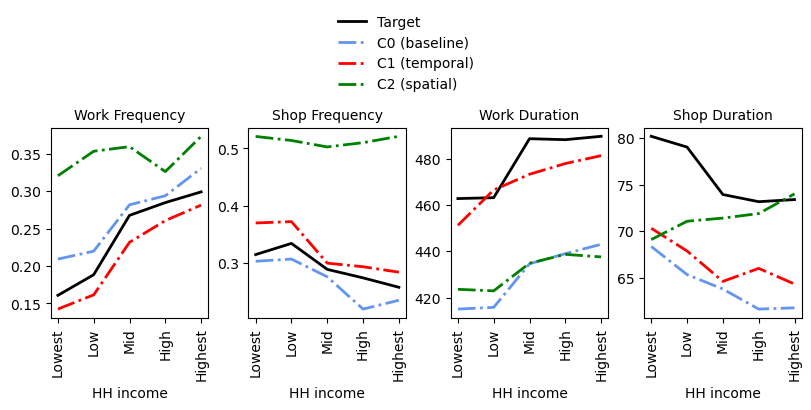

In [5]:
_ = plot_c(schedules, attributes, target_schedules, target_attributes)

In [8]:
training_data_route = Path("../../tmp/foundation/experiment_c")

target_schedules = pd.read_csv(training_data_route / "nts_activities_2024.csv")
target_attributes = pd.read_csv(training_data_route / "nts_attributes_2024.csv")

training_attributes = {
    "baseline": target_attributes,
    "temporal": pd.read_csv(
        training_data_route / "nts_attributes_no_2024_hh_income.csv"
    ),
    "spatial": pd.read_csv(
        training_data_route / "uk_attributes_no_2024_hh_income.csv"
    ),
    # "world": pd.read_csv(training_data_route / "western2_attributes.csv"),
}

training_schedules = {
    "baseline": target_schedules,
    "temporal": pd.read_csv(
        training_data_route / "nts_activities_no_2024_hh_income.csv"
    ),
    "spatial": pd.read_csv(
        training_data_route / "uk_activities_no_2024_hh_income.csv"
    ),
    # "world": pd.read_csv(training_data_route / "western2_activities.csv"),
}

In [9]:
counter = {}
# load each and get counts per source
counter["baseline"] = target_attributes.source.value_counts()
for name, data in training_attributes.items():
    print(data.source.unique())
    counter[name] = data.source.value_counts()
df = pd.DataFrame(counter)


order = ["nts", "ltds"]
df = df.loc[order].fillna(0)
totals = df.sum()
totals_row = pd.DataFrame([totals], index=["Total"])
df = pd.concat([df, totals_row])
print(df.to_latex(float_format="{:.0f}".format))

['nts']
['nts']
['ltds' 'nts']
\begin{tabular}{lrrr}
\toprule
 & baseline & temporal & spatial \\
\midrule
nts & 69826 & 401812 & 401812 \\
ltds & 0 & 0 & 37728 \\
Total & 69826 & 401812 & 439540 \\
\bottomrule
\end{tabular}

